# Lecture 4: Accessibility and Subplots

This notebook contains accessibility notes and the live coding activities from the June 10 data visualization class.

Potential accessibility issues include:

- Some text is small and difficult to read.
- Important information relies partly on colour.
- Text embedded in the image may not be read by screen readers.
- The figure does not provide an alternative written description of its main message.
- Low contrast or subtle visual elements may be difficult for some viewers to distinguish.

Alt-Text Activity

The most appropriate alt text depends on the purpose and context of an image.

"Professor Patrick Gunning and doctoral student Eugenia Duodu talking beside a chemistry fume hood in a laboratory."

Four Levels of Visualization Description

- Level 1: Chart type, title, axes, labels, colours, and ranges.
- Level 2: Descriptive statistics, maxima, minima, outliers, and comparisons.
- Level 3: Trends, patterns, clusters, and exceptions.
- Level 4: Domain context and subjective interpretations beyond the data.

In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import pandas as pd 
import scipy 
import PIL 
import requests

In [2]:
np.random.seed(613) 
# Numerical data for the scatter plot and line plot. 
x1 = np.arange(50) 
y1 = np.random.randint(0, 75, 50) 
# Categorical data for the bar plot. 
x2 = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"]) 
y2 = np.array([110, 180, 240, 99, 220])

/var/folders/h5/tkb1lw156hg_2dkhgndlm4dh0000gn/T/ipykernel_42338/1788435443.py:4: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


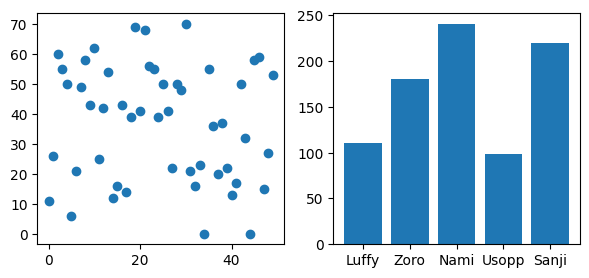

In [3]:
fig, (ax1, ax2) = plt.subplots( ncols=2, nrows=1, figsize=(7, 3), ) 
ax1.scatter(x1, y1) 
ax2.bar(x2, y2) 
fig.show()

Activity: Customizing the Subplots

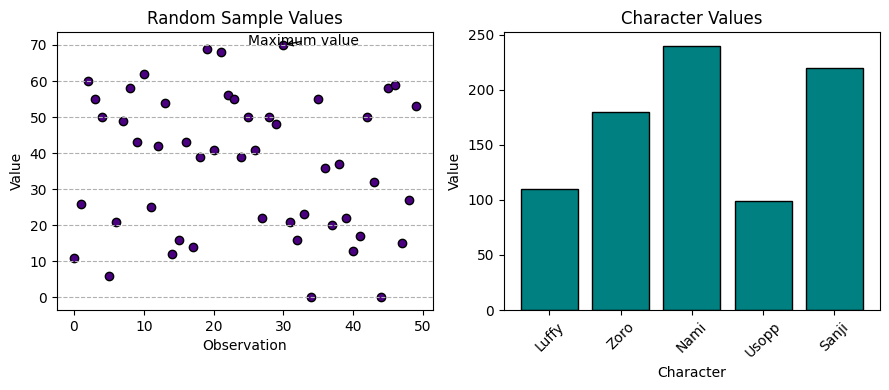

In [4]:
fig, (ax1, ax2) = plt.subplots(ncols=2, nrows=1, figsize=(9, 4),)
ax1.scatter( x1, y1, marker="o", color="indigo", edgecolor="black", )
ax1.set_title("Random Sample Values") 
ax1.set_xlabel("Observation") 
ax1.set_ylabel("Value") 
ax1.grid( axis="y", linestyle="--", linewidth=0.8, )
# Identify and annotate the maximum value.
max_index = np.argmax(y1) 
ax1.annotate( "Maximum value", 
xy=(x1[max_index], y1[max_index]), 
xytext=(25, 70), 
arrowprops={ "arrowstyle": "->", "color": "black", }, )
# Customize the bar plot.
ax2.bar( x2, y2, color="teal", edgecolor="black", ) 
ax2.set_title("Character Values") 
ax2.set_xlabel("Character") 
ax2.set_ylabel("Value") 
ax2.tick_params( axis="x", labelrotation=45, ) 
fig.tight_layout()

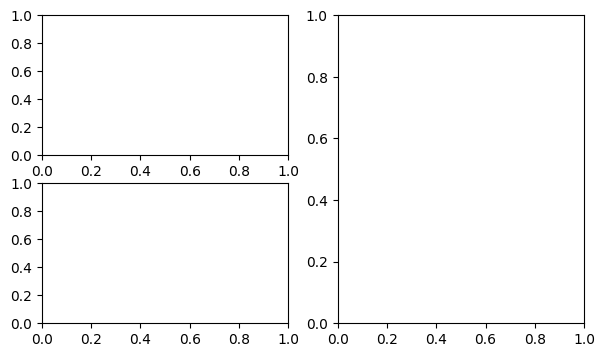

In [5]:
fig, someaxes = plt.subplot_mosaic( [ ["ax1", "ax3"], 
["ax2", "ax3"], ], 
figsize=(7, 4))

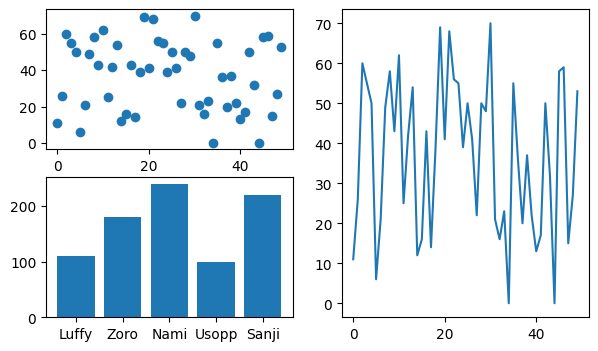

In [6]:
fig, someaxes = plt.subplot_mosaic( [ 
    ["ax1", "ax3"], 
    ["ax2", "ax3"], ], 
    figsize=(7, 4)) 
someaxes["ax1"].scatter(x1, y1) 
someaxes["ax2"].bar(x2, y2) 
someaxes["ax3"].plot(x1, y1) 
plt.show()

Layouts

Text(0.5, 0, 'Label 2: 2 Fast 2 Furious')

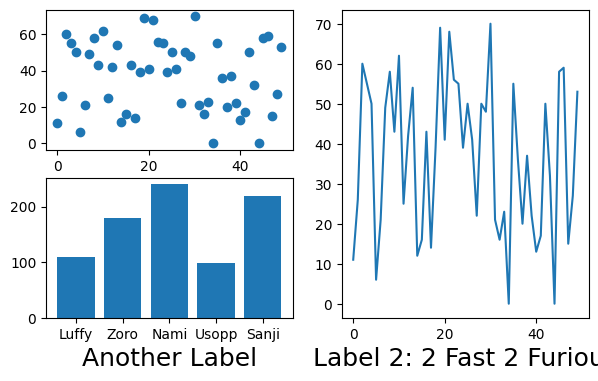

In [7]:
fig, someaxes = plt.subplot_mosaic( [ ["ax1", "ax3"], ["ax2", "ax3"], ], 
figsize=(7, 4), ) 
someaxes["ax1"].scatter(x1, y1) 
someaxes["ax2"].bar(x2, y2) 
someaxes["ax3"].plot(x1, y1) 
someaxes["ax1"].set_xlabel( "A Big Label", fontsize=18, )
someaxes["ax2"].set_xlabel( "Another Label", fontsize=18, ) 
someaxes["ax3"].set_xlabel( "Label 2: 2 Fast 2 Furious", fontsize=18, ) 

Constrained Layout

Text(0.5, 0, 'Label 2: 2 Fast 2 Furious')

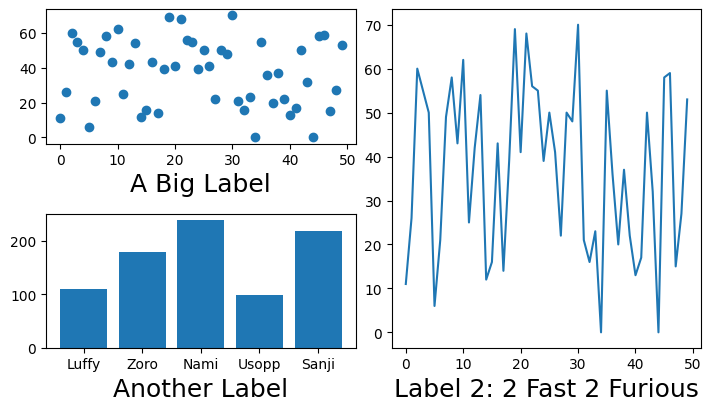

In [ ]:
fig, someaxes = plt.subplot_mosaic( [ ["ax1", "ax3"], ["ax2", "ax3"], ], 
figsize=(7, 4), layout="constrained", ) 
someaxes["ax1"].scatter(x1, y1) 
someaxes["ax2"].bar(x2, y2) 
someaxes["ax3"].plot(x1, y1) 
someaxes["ax1"].set_xlabel( "A Big Label", fontsize=18, )
someaxes["ax2"].set_xlabel( "Another Label", fontsize=18, ) 
someaxes["ax3"].set_xlabel( "Label 2: 2 Fast 2 Furious", fontsize=18 )

Multiple visualization

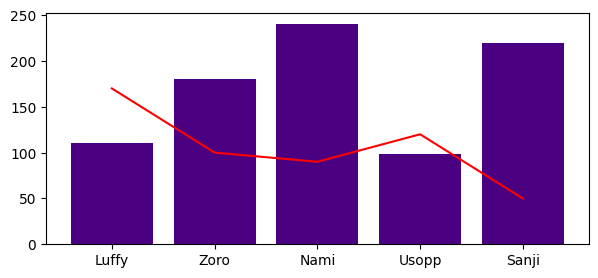

In [12]:
x = np.array(["Luffy", "Zoro", "Nami", "Usopp", "Sanji"]) 
y1 = np.array([110, 180, 240, 99, 220]) 
y2 = np.array([170, 100, 90, 120, 50])
fig, ax = plt.subplots(figsize=(7, 3)) 
ax.bar( x, y1, color="indigo")
ax.plot( x, y2, color="red" ) 


Standard Deviation

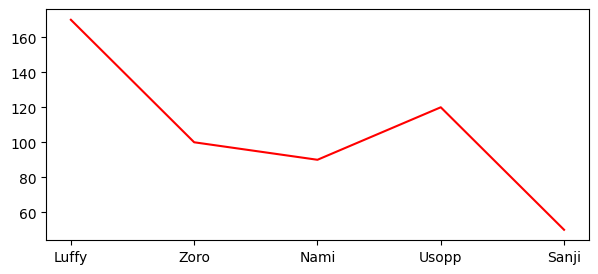

In [13]:
y2_sd = np.std(y2) 
y2_sd
fig, ax = plt.subplots(figsize=(7,3))
ax.plot(x,y2,color = "red")

In [14]:
ax.errorbar(x, y2, yerr=y2_sd, fmt="none",)

<ErrorbarContainer object of 3 artists>

<ErrorbarContainer object of 3 artists>

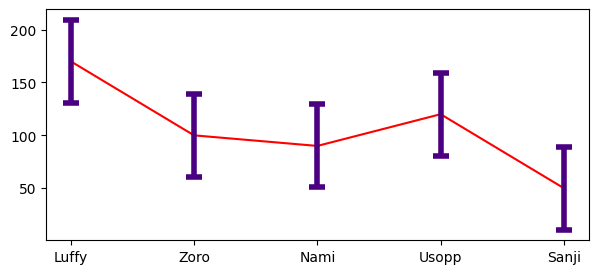

In [16]:
fig, ax = plt.subplots(figsize=(7, 3)) 
ax.plot( x, y2, color="red", ) 
ax.errorbar( x, y2, 
yerr=y2_sd, 
fmt="none", 
ecolor="indigo", 
elinewidth=4, 
capsize=6, 
capthick=4)

Errorevery

In [17]:
ax.errorbar( x, y2, 
yerr=y2_sd, 
fmt="none", 
ecolor="indigo", 
elinewidth=4, 
capsize=6, 
capthick=4, 
errorevery=2)

<ErrorbarContainer object of 3 artists>

In [21]:
from PIL import Image 
from io import BytesIO 
url = "https://upload.wikimedia.org/wikipedia/en/c/cb/Monkey_D_Luffy.png" 
headers = { "User-Agent": "Mozilla/5.0", "Accept": "image/*,*/*;q=0.8", "Referer": "https://en.wikipedia.org/", } 
response = requests.get( url, headers=headers)
image_file = BytesIO(response.content) 
image = Image.open(image_file)

(np.float64(-0.5), np.float64(219.5), np.float64(425.5), np.float64(-0.5))

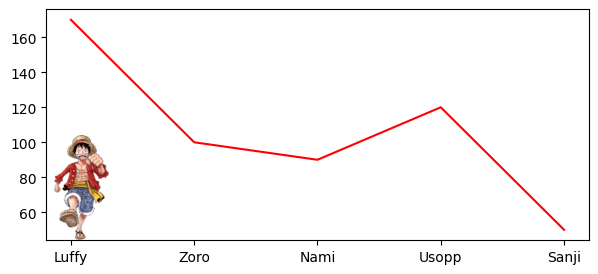

In [26]:
fig, ax = plt.subplots(figsize=(7, 3)) 
ax.plot( x, y2, color="red", )
ax_image = fig.add_axes( [ 0.1, 0.11, 0.15, 0.35])

ax_image.imshow(image) 
# Hide the image axes' border and tick marks. 
ax_image.axis("off")

In [35]:
# path = '/Users/xinxi/Desktop/DSI/visualization/'
filename = 'fig1a.png'

plt.savefig(filename, dpi=300)

<Figure size 640x480 with 0 Axes>

Course notes:
- avoiding reliance on colour alone
- using readable typefaces and sufficiently large text
- maintaining strong contrast
- clearly labelling visual elements
- whether the final visualization can be accessed across devices